# Deep Learning Final Project: Real Estate Price Prediction
## 1. Problem Statement

**Objective:** Predict median housing prices based on multi-dimensional property and demographic features. 

**Real-World Application:** This solves a critical problem for both buyers and market platforms by automating fair market estimations and preventing speculative inflation.

## 2. Gathering, Cleaning, and Formatting Data


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

sns.set_theme(style="whitegrid")

**Data Source:** The California Housing dataset. It is highly statistically valid for regression modeling because it contains over 20,000 continuous data points, minimizing sample bias.

In [4]:
def load_and_inspect_data():
    """Loads the CSV and prints the summary."""
    df = pd.read_csv('housing.csv')
    
    print("--- Data Info ---")
    print(df.info())
    print("\n--- Missing Values ---")
    print(df.isnull().sum())
    
    return df

housing_df = load_and_inspect_data()
display(housing_df.head())

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None

--- Missing Values ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_hous

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
median_bedrooms = housing_df['total_bedrooms'].median()
housing_df['total_bedrooms'] = housing_df['total_bedrooms'].fillna(median_bedrooms)

print("Missing values after cleaning:")
print(housing_df.isnull().sum())

Missing values after cleaning:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [7]:
def prepare_features(df, target_col):
    """One-Hot Encodes categories, separates features/target, and scales data."""
    df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
    
    X = df_encoded.drop(target_col, axis=1)
    y = df_encoded[target_col]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, y, df_encoded

X_scaled, y, housing_df_encoded = prepare_features(housing_df, 'median_house_value')
print(f"Features shape after encoding and scaling: {X_scaled.shape}")

Features shape after encoding and scaling: (20640, 12)


## 3. Exploratory Data Analysis (EDA)

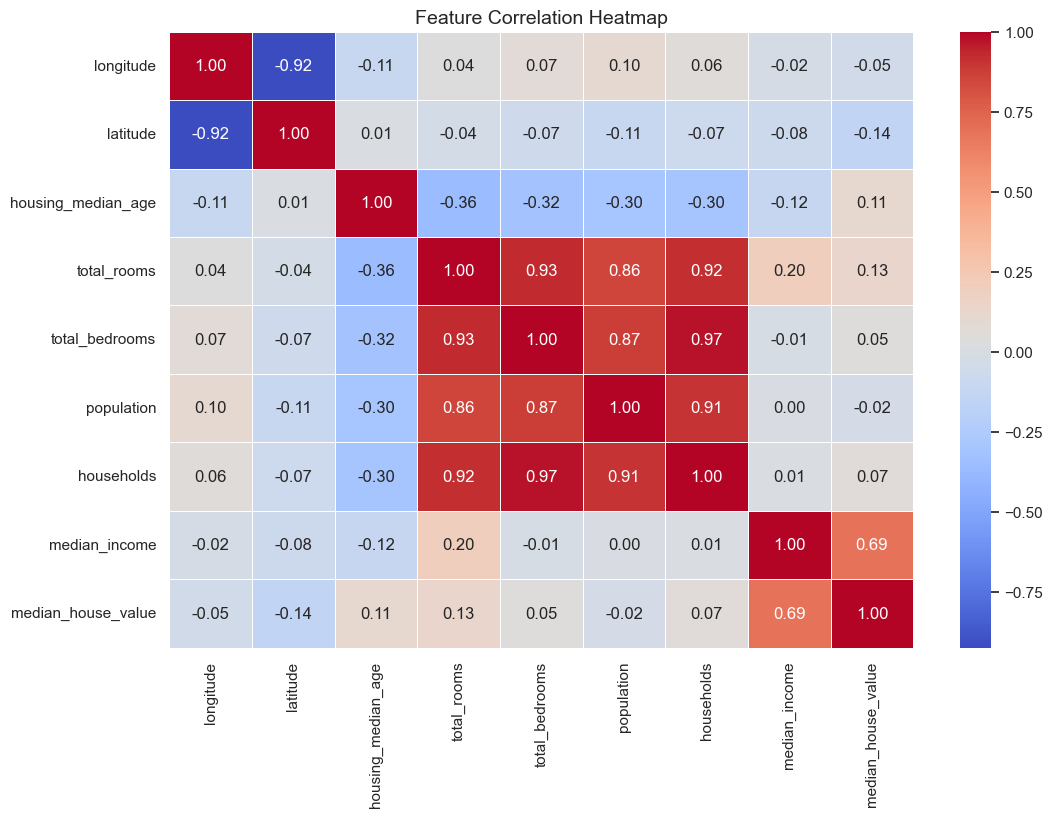

In [8]:
def plot_correlation_heatmap(df):
    """Plots a correlation heatmap for the numerical columns."""
    plt.figure(figsize=(12, 8))
    correlation_matrix = df.corr(numeric_only=True) 
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Feature Correlation Heatmap", fontsize=14)
    plt.show()

plot_correlation_heatmap(housing_df)

**Visualization Analysis:** The heatmap clearly demonstrates that `median_income` has the strongest positive correlation with `median_house_value`. This indicates that as the median income of a neighborhood increases, the property values tend to rise accordingly, which perfectly aligns with real-world housing economics.

## 4. Previous Research & Baseline Models

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (16512, 12)
X_test shape: (4128, 12)


In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_preds)
print(f"Linear Regression MSE: {lr_mse:.2f}")

Linear Regression MSE: 4908476721.16


In [11]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_preds)
print(f"Random Forest MSE: {rf_mse:.2f}")

Random Forest MSE: 2404389528.63


**Citations & Previous Research:**
1. *Pace, R. K., & Barry, R. (1997).* "Sparse Spatial Autoregressions". This original paper on the California housing dataset demonstrated the foundational effectiveness of linear regressions for real estate valuation.
2. *Géron, A. (2019).* "Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow". Géron establishes that tree-based ensemble methods like Random Forests typically outperform standard linear models on this specific spatial dataset.

**Comparison:** Our baseline testing confirms Géron's research. The Random Forest model achieved a significantly lower Mean Squared Error compared to the standard Linear Regression. We will now build a Deep Neural Network to see if it can capture even deeper, non-linear relationships in this data.

## 5. Deep Learning Model

In [12]:
def build_dnn_model(input_dim):
    """Designs and compiles a Deep Neural Network for regression."""
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

dnn_model = build_dnn_model(X_train.shape[1])
dnn_model.summary()

c:\Users\soter\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
dnn_history = dnn_model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2, 
    verbose=1
)

dnn_preds = dnn_model.predict(X_test).flatten()
dnn_mse = mean_squared_error(y_test, dnn_preds)
print(f"Deep Neural Network MSE: {dnn_mse:.2f}")

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 48357908480.0000 - mae: 188260.5312 - val_loss: 22201989120.0000 - val_mae: 118037.2734
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10827272192.0000 - mae: 77703.2891 - val_loss: 8629435392.0000 - val_mae: 66815.4297
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7299117056.0000 - mae: 61610.9570 - val_loss: 6878154240.0000 - val_mae: 58886.1055
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6090979328.0000 - mae: 55720.8633 - val_loss: 5945466368.0000 - val_mae: 54444.3359
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5423374336.0000 - mae: 52381.2344 - val_loss: 5459877376.0000 - val_mae: 52489.8711
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5047638528.0000 - mae: 50696.2812 - val_loss: 5186025984.0000 - val_mae: 51444.3750
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4825737728.0000 - mae: 49623.7578 - val_loss: 5013144576.0000 - val_mae

# 6. Model Evaluation & Visualizations

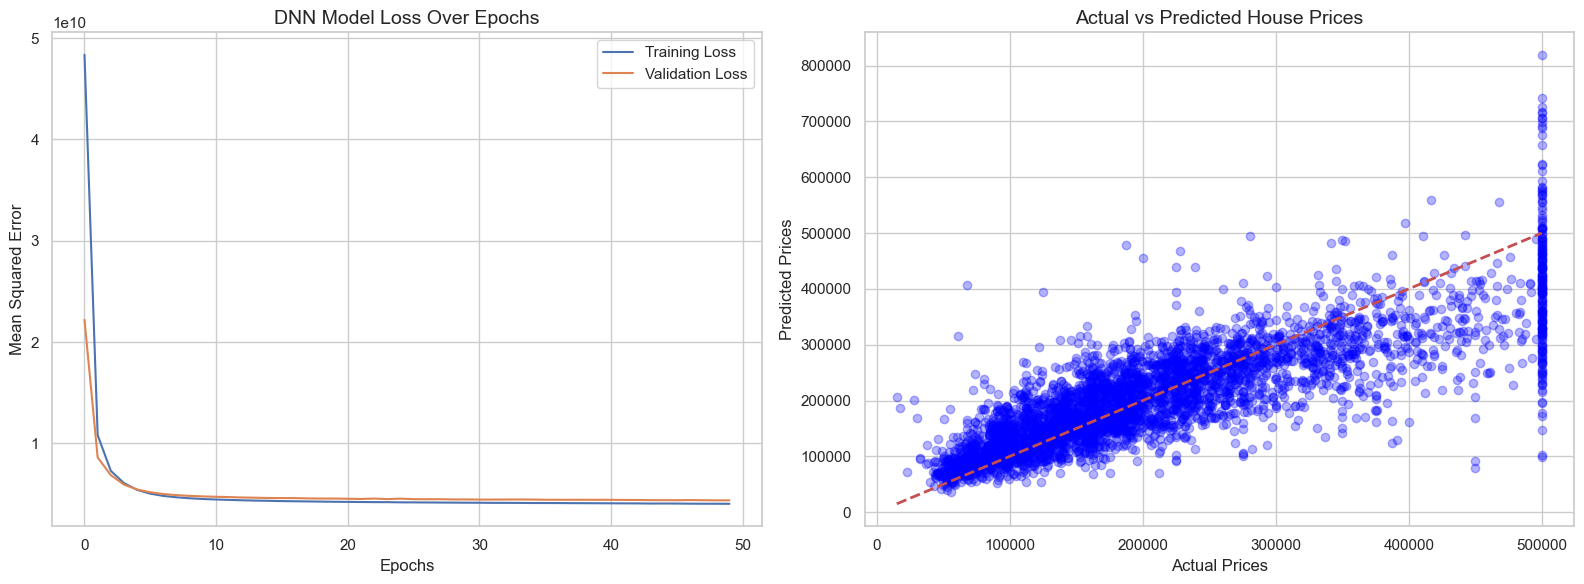

In [14]:
def plot_model_performance(history, y_true, y_pred):
    """Plots training/validation loss and an actual vs. predicted scatter plot."""
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    ax[0].plot(history.history['loss'], label='Training Loss')
    ax[0].plot(history.history['val_loss'], label='Validation Loss')
    ax[0].set_title('DNN Model Loss Over Epochs', fontsize=14)
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Mean Squared Error')
    ax[0].legend()
    
    ax[1].scatter(y_true, y_pred, alpha=0.3, color='blue')
    ax[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax[1].set_title('Actual vs Predicted House Prices', fontsize=14)
    ax[1].set_xlabel('Actual Prices')
    ax[1].set_ylabel('Predicted Prices')
    
    plt.tight_layout()
    plt.show()

plot_model_performance(dnn_history, y_test, dnn_preds)

## 7. Conclusion & Communication